## Support Vector Machines (SVMs): The Primal Optimization Problem

In this notebook, we will optimize the SVMs primal objective with stochastic subgradient descent.

Check out the [blog post](https://github.com/didarulilm/ml-notebooks) where I explained how to derive the optimization problem from scratch.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

In [5]:
dataset = pd.read_csv("../datasets/svm_data.csv")
dataset

,Feature 1,Feature 2,Label
0,3.764052,2.400157,0.0
1,0.729515,2.969397,0.0
2,0.826877,3.943621,0.0
3,1.586381,1.252545,0.0
4,3.922942,3.480515,0.0
...,...,...,...
295,-0.647181,0.472247,1.0
296,0.930408,-0.175316,1.0
297,-1.421920,1.997956,1.0
298,-0.856549,-1.541587,1.0


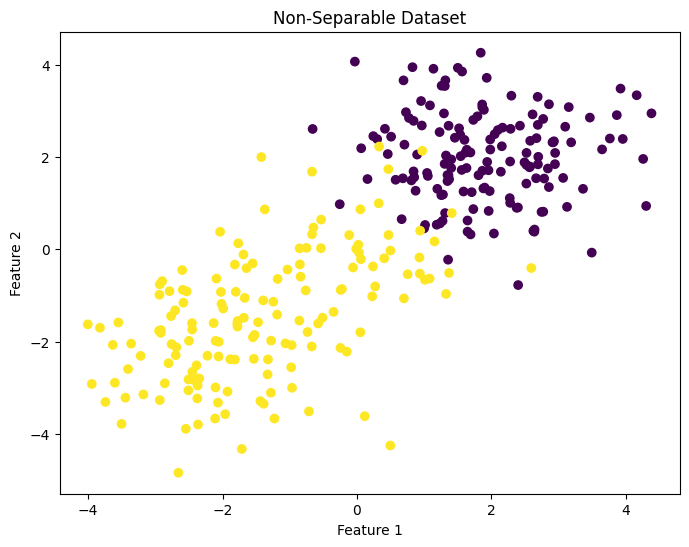

In [6]:
features = dataset.drop("Label", axis=1).values
labels = dataset["Label"].values
transformed_labels = np.where(labels == 1, 1, -1)

# Plot the dataset
plt.figure(figsize=(8, 6))
plt.scatter(features[:, 0], features[:, 1], c=transformed_labels)
plt.title("Non-Separable Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Split the dataset into training and test set
features_train, features_test, labels_train, labels_test = train_test_split(
    features, transformed_labels, test_size=0.2
)

### Cost Function, Gradient, and Inference

We know our cost function $J(w)$ with the **hinge loss** function can be expressed as
$$
J(w)=\frac{1}{M}\sum_{i=1}^{M} \biggl\{ {\frac{\lambda}{2}||w||^2} + \max(0, 1 - y_i(w^Tx_i)) \biggl\}
$$

The subgradient of the cost function is given by
$$
\tilde{\nabla}_{w}J(w) = \frac{1}{M}\sum_{i=1}^{M} \begin{cases} 
\lambda w - y_ix_i&\quad \text{if } y_i(w^Tx_i) < 1\\
\lambda w  &\quad \text{otherwise} 
\end{cases}
$$

After training, we can evaluate the model on unseen test data. For any test instance $x_{test}$, the predicted label is:
$$
y_{pred}​=sign(w^Tx_{test}​)
$$

where $w_0=b$ in the weight vector $w$.
